/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5748/2670397944.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


                                                 text  cluster
0   adelaide Adelaide Adelaide Street Circuit  STR...        1
1   aida Aida Okayama International Circuit TI Cir...        2
2   ain-diab Ain-Diab Ain-Diab Circuit  ROAD CLOCK...        2
3   aintree Aintree Aintree Motor Racing Circuit  ...        1
4   anderstorp Anderstorp Raceway Anderstorp Racew...        2
5   austin Americas Circuit of the Americas  RACE ...        1
6   avus AVUS AVUS  ROAD ANTI_CLOCKWISE Berlin ger...        3
7   bahrain Bahrain Bahrain International Circuit ...        2
8   baku Baku Baku City Circuit  STREET ANTI_CLOCK...        1
9   brands-hatch Brands Hatch Brands Hatch  RACE C...        1
10  bremgarten Bremgarten Circuit Bremgarten  ROAD...        2
11  buddh Buddh Buddh International Circuit  RACE ...        2
12  buenos-aires Juan y Oscar Gálvez Autódromo Jua...        2
13  bugatti Bugatti Bugatti Circuit  RACE CLOCKWIS...        2
14  caesars-palace Caesars Palace Caesars Palace  ...  

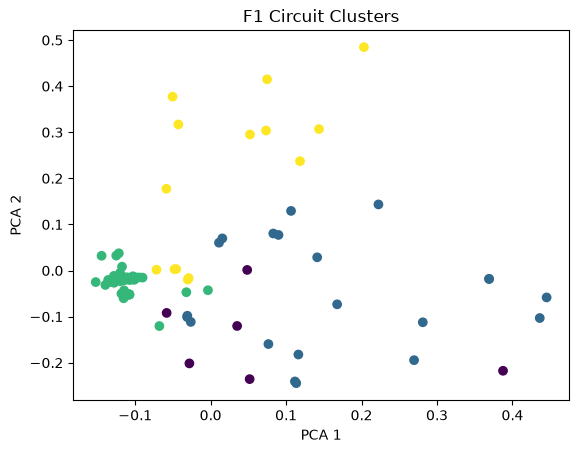

In [1]:
# F1 Circuits: NLP + K-Means

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv("f1db-circuits.csv")

# 2. Combine text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").agg(" ".join, axis=1)

# 3. NLP - TF-IDF
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["text"])

# 4. K-Means
k = 4
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 5. Show results
print(df[["text", "cluster"]].head(20))

# 6. Visualise clusters
X_pca = PCA(n_components=2).fit_transform(X.toarray())

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("F1 Circuit Clusters")
plt.show()

# 7. Save results
df.to_csv("f1db-circuits-clustered.csv", index=False)